In [11]:
import pandas as pd
df = pd.read_csv((r'C:\Users\axel_\Documents\conda\random-games\playerStats\csv\arsenal-vs-atletico-madrid-v1.csv'))
df.head()

,name,id,optaId,teamId,teamName,isGoalkeeper,stats,shirtNumber,positionId,usualPosition,...,gk_saves,gk_goals_conceded,gk_xGOT_faced,gk_goals_prevented,gk_diving_save,gk_saves_inside_box,gk_acted_as_sweeper,gk_punches,gk_throws,gk_high_claim
0,Jan Oblak,177126,81352,9906,Atlético de Madrid,True,"[{'title': 'Top stats', 'key': 'top_stats', 's...",13,11.0,0,...,1.0,1.0,0.7,-0.3,0.0,0.0,2.0,0.0,3.0,0.0
1,Antoine Griezmann,184138,76650,9906,Atlético de Madrid,False,"[{'title': 'Top stats', 'key': 'top_stats', 's...",7,104.0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Koke,184533,77390,9906,Atlético de Madrid,False,"[{'title': 'Top stats', 'key': 'top_stats', 's...",6,74.0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Christian Nørgaard,266520,128295,9825,Arsenal,False,[],16,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kepa Arrizabalaga,317564,109745,9825,Arsenal,True,[],13,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.columns

Index(['name', 'id', 'optaId', 'teamId', 'teamName', 'isGoalkeeper', 'stats',
       'shirtNumber', 'positionId', 'usualPosition', 'matchId', 'matchRound',
       'homeTeamName', 'homeTeamid', 'awayTeamName', 'awayTeamid', 'matchDate',
       'home_goals', 'away_goals', 'FotMob_rating', 'Minutes_played', 'Goals',
       'Assists', 'Total_shots', 'Accurate_passes_value',
       'Accurate_passes_total', 'Chances_created', 'Expected_assists_xA',
       'xG_plus_xA', 'Fantasy_points', 'Defensive_actions', 'touches',
       'touches_opp_box', 'passes_into_final_third', 'accurate_crosses_value',
       'accurate_crosses_total', 'long_balls_accurate_value',
       'long_balls_accurate_total', 'dispossessed', 'tackles_succeeded_value',
       'tackles_succeeded_total', 'shot_blocks', 'clearances',
       'headed_clearance', 'interceptions', 'recoveries', 'dribbled_past',
       'duel_won', 'duel_lost', 'ground_duels_won_value',
       'ground_duels_won_total', 'aerials_won_value', 'aerials_won

In [21]:
df[['name', 'Accurate_passes_value', 'Accurate_passes_total', 'Chances_created', 'touches', 'Goals', 'shots_off_target', 'shots_on_target', 'shot_accuracy', 'Total_shots']].head()

,name,Accurate_passes_value,Accurate_passes_total,Chances_created,touches,Goals,shots_off_target,shots_on_target,shot_accuracy,Total_shots
0,Jan Oblak,23.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Antoine Griezmann,39.0,48.0,2.0,62.0,0.0,1.0,0.0,0.0,NaN
2,Koke,58.0,70.0,1.0,81.0,0.0,NaN,NaN,NaN,NaN
3,Christian Nørgaard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kepa Arrizabalaga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# df with passes
w_df = df[['name', 'Accurate_passes_value', 'Accurate_passes_total']]
w_df.head()

,name,Accurate_passes_value,Accurate_passes_total
0,Jan Oblak,23.0,39.0
1,Antoine Griezmann,39.0,48.0
2,Koke,58.0,70.0
3,Christian Nørgaard,NaN,NaN
4,Kepa Arrizabalaga,NaN,NaN


In [13]:
# drop NA
w_df = w_df.dropna(subset=['Accurate_passes_value'])
w_df

,name,Accurate_passes_value,Accurate_passes_total
0,Jan Oblak,23.0,39.0
1,Antoine Griezmann,39.0,48.0
2,Koke,58.0,70.0
5,Leandro Trossard,12.0,12.0
9,Martin Ødegaard,32.0,35.0
10,David Raya,19.0,27.0
11,Gabriel Jesus,6.0,8.0
12,Marcos Llorente,30.0,32.0
13,Robin Le Normand,31.0,34.0
14,Declan Rice,83.0,89.0


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from pywaffle import Waffle

In [14]:
# sort data by accurate passes value
w_df = w_df.sort_values(by=['Accurate_passes_total'], ascending=False)
w_df.head()

,name,Accurate_passes_value,Accurate_passes_total
14,Declan Rice,83.0,89.0
2,Koke,58.0,70.0
18,Dávid Hancko,58.0,67.0
24,William Saliba,59.0,62.0
28,Martín Zubimendi,46.0,51.0


In [15]:
# transpose the df
w_df = w_df.T
w_df.head()

,14,2,18,24,28,33,20,1,29,0,...,27,21,34,5,25,15,11,22,17,37
name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_value,83.0,58.0,58.0,59.0,46.0,42.0,45.0,39.0,39.0,23.0,...,19.0,17.0,10.0,12.0,10.0,6.0,6.0,4.0,2.0,3.0
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0


In [18]:
# remove indexs at the top
w_df.columns = w_df.iloc[0]
w_df.head()

name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_value,83.0,58.0,58.0,59.0,46.0,42.0,45.0,39.0,39.0,23.0,...,19.0,17.0,10.0,12.0,10.0,6.0,6.0,4.0,2.0,3.0
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0


In [19]:
# drop the player names rows
w_df = w_df.drop('name')
w_df.head()

name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_value,83.0,58.0,58.0,59.0,46.0,42.0,45.0,39.0,39.0,23.0,...,19.0,17.0,10.0,12.0,10.0,6.0,6.0,4.0,2.0,3.0
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0


In [20]:
# create list with the columns
my_list = w_df.columns.values.tolist()
my_list

['Declan Rice',
 'Koke',
 'Dávid Hancko',
 'William Saliba',
 'Martín Zubimendi',
 'Johnny Cardoso',
 'Gabriel',
 'Antoine Griezmann',
 'Matteo Ruggeri',
 'Jan Oblak',
 'Marc Pubill',
 'Piero Hincapié',
 'Martin Ødegaard',
 'Robin Le Normand',
 'Marcos Llorente',
 'Ademola Lookman',
 'Julián Álvarez',
 'David Raya',
 'Ben White',
 'Noni Madueke',
 'Gabriel Martinelli',
 'Eberechi Eze',
 'Giuliano Simeone',
 'Leandro Trossard',
 'Bukayo Saka',
 'Viktor Gyökeres',
 'Gabriel Jesus',
 'Álex Baena',
 'Nahuel Molina',
 'Cristhian Mosquera']

In [21]:
# new df with my_list for the columns
w_df = pd.DataFrame(w_df, columns=my_list)
w_df.head()

,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_value,83.0,58.0,58.0,59.0,46.0,42.0,45.0,39.0,39.0,23.0,...,19.0,17.0,10.0,12.0,10.0,6.0,6.0,4.0,2.0,3.0
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0


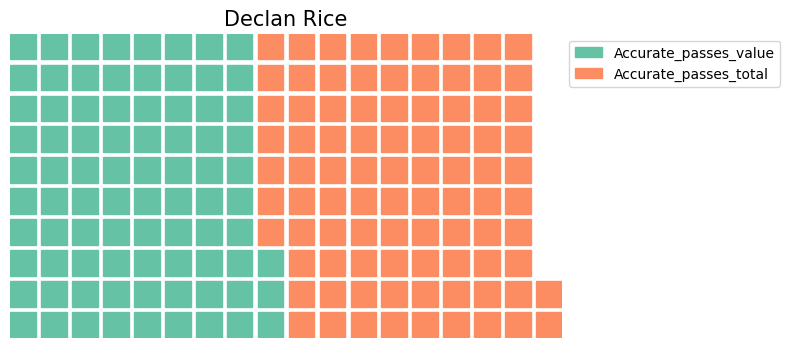

In [76]:
fig = plt.figure(
    FigureClass=Waffle,
    values=w_df.iloc[:,0],
    labels=list(w_df.index),
    rows=10,
    title={
        'label':my_list[0],
        'fontdict': {
            'fontsize': 15
        }
    },
    figsize=(8,4),
    legend={
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1)
    },
)